In [ ]:
# We're bringing in the tools we need for this week
# Think of imports like opening your toolbox before starting work

import pandas as pd          # pandas handles our data like a spreadsheet
import numpy as np           # numpy handles numbers and math operations
import matplotlib.pyplot as plt  # matplotlib draws charts and graphs
import seaborn as sns        # seaborn makes prettier charts, built on matplotlib
import os                    # os lets us work with files and folders

# This line makes sure charts appear right inside the notebook
%matplotlib inline

# This makes seaborn charts look clean and professional
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully")

✅ Libraries loaded successfully


In [ ]:
# pd.read_csv() reads a CSV file and converts it into a DataFrame
# A DataFrame is like an Excel spreadsheet inside Python
# index_col=0 means "use the first column as the row index, not as data"

df = pd.read_csv("data/dataset.csv")

# Loading the 3 supporting files — same idea
desc_df = pd.read_csv("data/symptom_Description.csv")
prec_df = pd.read_csv("data/symptom_precaution.csv")
sev_df  = pd.read_csv("data/symptom_severity.csv")

print("All 4 files loaded")
print(f"Main dataset shape: {df.shape}")
# .shape tells us (number of rows, number of columns)
# rows = patient cases, columns = symptoms + disease

✅ All 4 files loaded
Main dataset shape: (4920, 18)


In [ ]:
# .head() shows the first 5 rows of your data
# This is always the first thing you do with any new dataset
# It's like opening a book to page 1

df.head()


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Let's peek at each supporting file the same way

print("=== Disease Descriptions ===")
print(desc_df.head(3))  # head(3) means show first 3 rows only

print("\n=== Precautions ===")         # \n just adds a blank line
print(prec_df.head(3))

print("\n=== Symptom Severity ===")
print(sev_df.head(3))


=== Disease Descriptions ===
         Disease                                        Description
0  Drug Reaction  An adverse drug reaction (ADR) is an injury ca...
1        Malaria  An infectious disease caused by protozoan para...
2        Allergy  An allergy is an immune system response to a f...

=== Precautions ===
         Disease              Precaution_1              Precaution_2  \
0  Drug Reaction           stop irritation  consult nearest hospital   
1        Malaria  Consult nearest hospital           avoid oily food   
2        Allergy            apply calamine   cover area with bandage   

         Precaution_3                 Precaution_4  
0    stop taking drug                    follow up  
1  avoid non veg food           keep mosquitos out  
2                 NaN  use ice to compress itching  

=== Symptom Severity ===
                Symptom  weight
0               itching       1
1             skin_rash       3
2  nodal_skin_eruptions       4


In [ ]:
print(df.shape)

(4920, 18)


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Disease     4920 non-null   str  
 1   Symptom_1   4920 non-null   str  
 2   Symptom_2   4920 non-null   str  
 3   Symptom_3   4920 non-null   str  
 4   Symptom_4   4572 non-null   str  
 5   Symptom_5   3714 non-null   str  
 6   Symptom_6   2934 non-null   str  
 7   Symptom_7   2268 non-null   str  
 8   Symptom_8   1944 non-null   str  
 9   Symptom_9   1692 non-null   str  
 10  Symptom_10  1512 non-null   str  
 11  Symptom_11  1194 non-null   str  
 12  Symptom_12  744 non-null    str  
 13  Symptom_13  504 non-null    str  
 14  Symptom_14  306 non-null    str  
 15  Symptom_15  240 non-null    str  
 16  Symptom_16  192 non-null    str  
 17  Symptom_17  72 non-null     str  
dtypes: str(18)
memory usage: 1.2 MB


In [ ]:
print(df.isnull().sum())

Disease          0
Symptom_1        0
Symptom_2        0
Symptom_3        0
Symptom_4      348
Symptom_5     1206
Symptom_6     1986
Symptom_7     2652
Symptom_8     2976
Symptom_9     3228
Symptom_10    3408
Symptom_11    3726
Symptom_12    4176
Symptom_13    4416
Symptom_14    4614
Symptom_15    4680
Symptom_16    4728
Symptom_17    4848
dtype: int64


In [ ]:
# First problem: some symptoms have accidental spaces
# .str.strip() removes leading and trailing spaces from text

# We loop through only the symptom columns, not the Disease column
symptom_cols = [col for col in df.columns if col != 'Disease']
# This line creates a list of all column names except 'Disease'
# col for col in df.columns = go through every column name
# if col != 'Disease' = only keep it if it's not the Disease column

for col in symptom_cols:
    # For each symptom column, strip spaces and also replace inner spaces
    df[col] = df[col].str.strip()
    # .str.strip() works on the whole column at once
    # it removes spaces from start and end of each cell's text

print("Spaces stripped")
print("Example - Symptom_1 unique values sample:")
print(df['Symptom_1'].unique()[:10])
# .unique() shows all unique values in a column
# [:10] means show only first 10 of them

✅ Spaces stripped
Example - Symptom_1 unique values sample:
<ArrowStringArray>
[            'itching',           'skin_rash', 'continuous_sneezing',
           'shivering',        'stomach_pain',             'acidity',
            'vomiting',         'indigestion',      'muscle_wasting',
   'patches_in_throat']
Length: 10, dtype: str


In [ ]:
print(df.head())

            Disease  Symptom_1             Symptom_2             Symptom_3  \
0  Fungal infection    itching             skin_rash  nodal_skin_eruptions   
1  Fungal infection  skin_rash  nodal_skin_eruptions   dischromic _patches   
2  Fungal infection    itching  nodal_skin_eruptions   dischromic _patches   
3  Fungal infection    itching             skin_rash   dischromic _patches   
4  Fungal infection    itching             skin_rash  nodal_skin_eruptions   

             Symptom_4 Symptom_5 Symptom_6 Symptom_7 Symptom_8 Symptom_9  \
0  dischromic _patches       NaN       NaN       NaN       NaN       NaN   
1                  NaN       NaN       NaN       NaN       NaN       NaN   
2                  NaN       NaN       NaN       NaN       NaN       NaN   
3                  NaN       NaN       NaN       NaN       NaN       NaN   
4                  NaN       NaN       NaN       NaN       NaN       NaN   

  Symptom_10 Symptom_11 Symptom_12 Symptom_13 Symptom_14 Symptom_15  \
0  

In [ ]:
# First problem: some symptoms have accidental spaces
# Example: "dischromic _patches" has a space before underscore
# That would make it a DIFFERENT symptom from "dischromic_patches"
# .str.strip() removes leading and trailing spaces from text

# We loop through only the symptom columns, not the Disease column
symptom_cols = [col for col in df.columns if col != 'Disease']
# This line creates a list of all column names except 'Disease'
# col for col in df.columns = go through every column name
# if col != 'Disease' = only keep it if it's not the Disease column

for col in symptom_cols:
    # For each symptom column, strip spaces and also replace inner spaces
    df[col] = df[col].str.strip()
    # .str.strip() works on the whole column at once
    # it removes spaces from start and end of each cell's text

print("Spaces stripped")
print("Example - Symptom_1 unique values sample:")
print(df['Symptom_1'].unique()[:10])
# .unique() shows all unique values in a column
# [:10] means show only first 10 of them

✅ Spaces stripped
Example - Symptom_1 unique values sample:
<ArrowStringArray>
[            'itching',           'skin_rash', 'continuous_sneezing',
           'shivering',        'stomach_pain',             'acidity',
            'vomiting',         'indigestion',      'muscle_wasting',
   'patches_in_throat']
Length: 10, dtype: str


In [ ]:
# Right now we have 17 symptom columns side by side (wide format)
# We want to melt them into one single column (long format)
# 
# Wide format (current):
# Disease    | Symptom_1 | Symptom_2 | Symptom_3
# Flu        | fever      | cough     | NaN
#
# Long format (what we want):
# Disease | Symptom
# Flu     | fever
# Flu     | cough
# (NaN row disappears)
#
# pd.melt() does this reshaping for us

df_long = pd.melt(
    df,                          # which dataframe to reshape
    id_vars=['Disease'],         # which column to keep as-is (our label)
    value_vars=symptom_cols,     # which columns to melt into one
    value_name='Symptom'         # name of the new combined column
)

# After melting, NaN rows still exist — we drop them now
# dropna() removes any row that has a NaN value
# inplace=True means change the dataframe directly, don't create a copy
df_long.dropna(inplace=True)

# .strip() one more time on the new Symptom column to be safe
df_long['Symptom'] = df_long['Symptom'].str.strip()

print(f"Long format shape: {df_long.shape}")
print(df_long.head(10))
# Show first 10 rows so we can see the new structure

Long format shape: (36648, 3)
            Disease   variable    Symptom
0  Fungal infection  Symptom_1    itching
1  Fungal infection  Symptom_1  skin_rash
2  Fungal infection  Symptom_1    itching
3  Fungal infection  Symptom_1    itching
4  Fungal infection  Symptom_1    itching
5  Fungal infection  Symptom_1  skin_rash
6  Fungal infection  Symptom_1    itching
7  Fungal infection  Symptom_1    itching
8  Fungal infection  Symptom_1    itching
9  Fungal infection  Symptom_1    itching


In [ ]:
# Now let's understand what we're actually working with

num_diseases = df['Disease'].nunique()
# .nunique() counts how many UNIQUE values exist in a column

num_symptoms = df_long['Symptom'].nunique()
# Same thing but on our long format symptom column

print(f"Total diseases in dataset: {num_diseases}")
print(f"Total unique symptoms: {num_symptoms}")

print("\n--- All Disease Names ---")
print(sorted(df['Disease'].unique()))
# sorted() arranges them alphabetically
# .unique() gives us each disease name once, no repeats

Total diseases in dataset: 41
Total unique symptoms: 131

--- All Disease Names ---
['(vertigo) Paroymsal  Positional Vertigo', 'AIDS', 'Acne', 'Alcoholic hepatitis', 'Allergy', 'Arthritis', 'Bronchial Asthma', 'Cervical spondylosis', 'Chicken pox', 'Chronic cholestasis', 'Common Cold', 'Dengue', 'Diabetes ', 'Dimorphic hemmorhoids(piles)', 'Drug Reaction', 'Fungal infection', 'GERD', 'Gastroenteritis', 'Heart attack', 'Hepatitis B', 'Hepatitis C', 'Hepatitis D', 'Hepatitis E', 'Hypertension ', 'Hyperthyroidism', 'Hypoglycemia', 'Hypothyroidism', 'Impetigo', 'Jaundice', 'Malaria', 'Migraine', 'Osteoarthristis', 'Paralysis (brain hemorrhage)', 'Peptic ulcer diseae', 'Pneumonia', 'Psoriasis', 'Tuberculosis', 'Typhoid', 'Urinary tract infection', 'Varicose veins', 'hepatitis A']


In [ ]:
# Fix the Disease column in our ORIGINAL wide dataframe
# and in the long format dataframe both

# .str.strip() removes spaces from start and end
df['Disease'] = df['Disease'].str.strip()
df_long['Disease'] = df_long['Disease'].str.strip()

# Let's verify the problem ones are fixed
print("Checking fixed names:")
print(df['Disease'].unique())
# Now 'Diabetes ' should show as 'Diabetes'
# and 'Hypertension ' should show as 'Hypertension'

Checking fixed names:
<ArrowStringArray>
[                       'Fungal infection',
                                 'Allergy',
                                    'GERD',
                     'Chronic cholestasis',
                           'Drug Reaction',
                     'Peptic ulcer diseae',
                                    'AIDS',
                                'Diabetes',
                         'Gastroenteritis',
                        'Bronchial Asthma',
                            'Hypertension',
                                'Migraine',
                    'Cervical spondylosis',
            'Paralysis (brain hemorrhage)',
                                'Jaundice',
                                 'Malaria',
                             'Chicken pox',
                                  'Dengue',
                                 'Typhoid',
                             'hepatitis A',
                             'Hepatitis B',
                             'Hepat

In [ ]:
# Symptoms have underscores instead of spaces (fever not f_e_v_er)
# That's fine and intentional — underscores are cleaner for ML
# But let's check if any symptoms look weird or duplicated

print("All 131 unique symptoms (sorted alphabetically):")
print(sorted(df_long['Symptom'].unique()))


All 131 unique symptoms (sorted alphabetically):
['abdominal_pain', 'abnormal_menstruation', 'acidity', 'acute_liver_failure', 'altered_sensorium', 'anxiety', 'back_pain', 'belly_pain', 'blackheads', 'bladder_discomfort', 'blister', 'blood_in_sputum', 'bloody_stool', 'blurred_and_distorted_vision', 'breathlessness', 'brittle_nails', 'bruising', 'burning_micturition', 'chest_pain', 'chills', 'cold_hands_and_feets', 'coma', 'congestion', 'constipation', 'continuous_feel_of_urine', 'continuous_sneezing', 'cough', 'cramps', 'dark_urine', 'dehydration', 'depression', 'diarrhoea', 'dischromic _patches', 'distention_of_abdomen', 'dizziness', 'drying_and_tingling_lips', 'enlarged_thyroid', 'excessive_hunger', 'extra_marital_contacts', 'family_history', 'fast_heart_rate', 'fatigue', 'fluid_overload', 'foul_smell_of urine', 'headache', 'high_fever', 'hip_joint_pain', 'history_of_alcohol_consumption', 'increased_appetite', 'indigestion', 'inflammatory_nails', 'internal_itching', 'irregular_sugar_

In [ ]:
# This is crucial — we need to know if our dataset is BALANCED
# Balanced means: roughly equal number of cases per disease
# Imbalanced means: some diseases have 1000 cases, others have 10
# An imbalanced dataset makes ML models biased toward common diseases

disease_counts = df['Disease'].value_counts()
# .value_counts() counts how many rows exist for each unique disease
# It automatically sorts from most common to least common

print(f"Cases per disease:")
print(disease_counts)
print(f"\nMin cases for any disease: {disease_counts.min()}")
print(f"Max cases for any disease: {disease_counts.max()}")

Cases per disease:
Disease
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                                    120
hepatitis A                                120
Hepatitis B                      

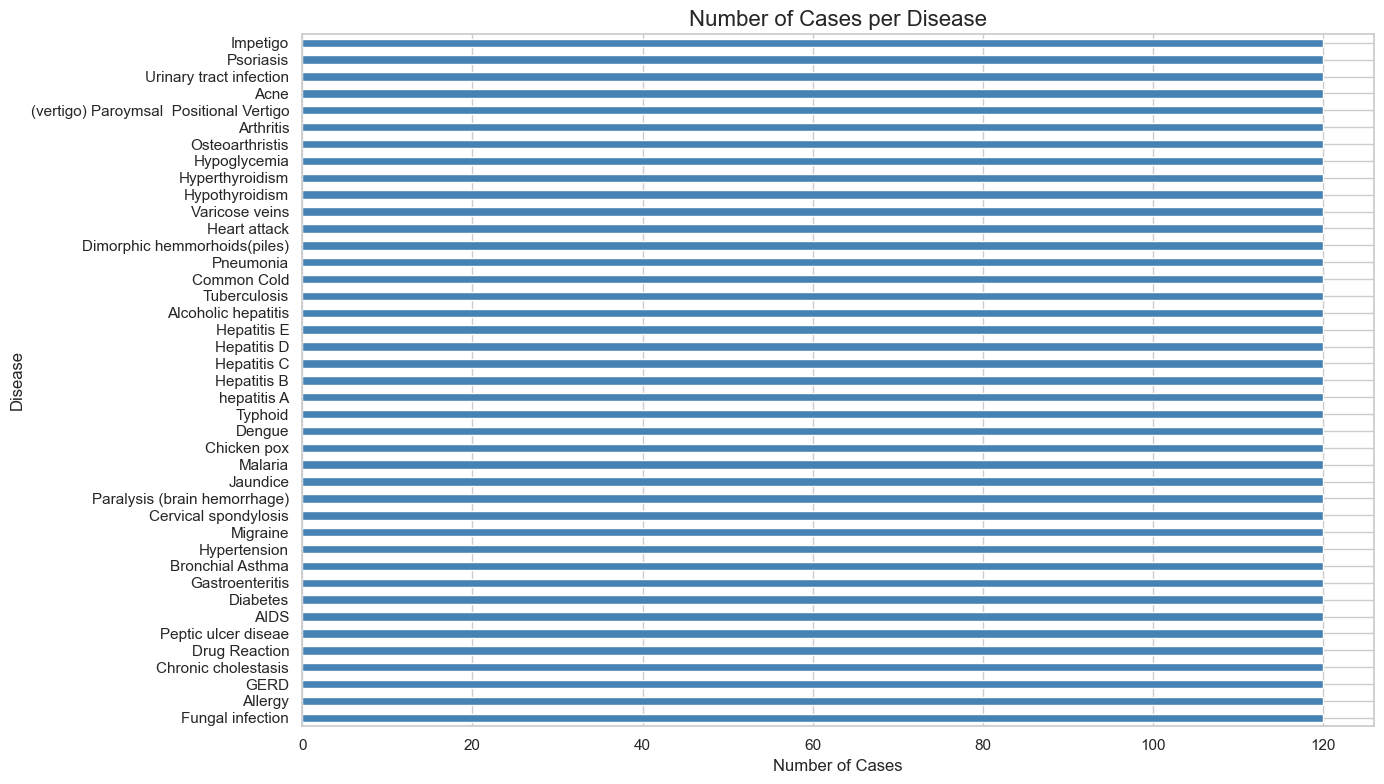

✅ Chart saved


In [ ]:
# Now let's see this as a chart
# A picture is always clearer than numbers for spotting imbalance

plt.figure(figsize=(14, 8))
# figsize=(width, height) in inches — we need wide chart for 41 diseases

disease_counts.plot(kind='barh', color='steelblue')
# kind='barh' means horizontal bar chart
# horizontal because we have 41 long disease names — vertical would overlap

plt.title('Number of Cases per Disease', fontsize=16)
plt.xlabel('Number of Cases', fontsize=12)
plt.ylabel('Disease', fontsize=12)
plt.tight_layout()
# tight_layout() prevents labels from getting cut off at edges

plt.savefig('data/disease_distribution.png', dpi=150, bbox_inches='tight')
# We save every chart to the data folder so we have them for the README later
# dpi=150 means good resolution, not blurry

plt.show()
print("Chart saved")


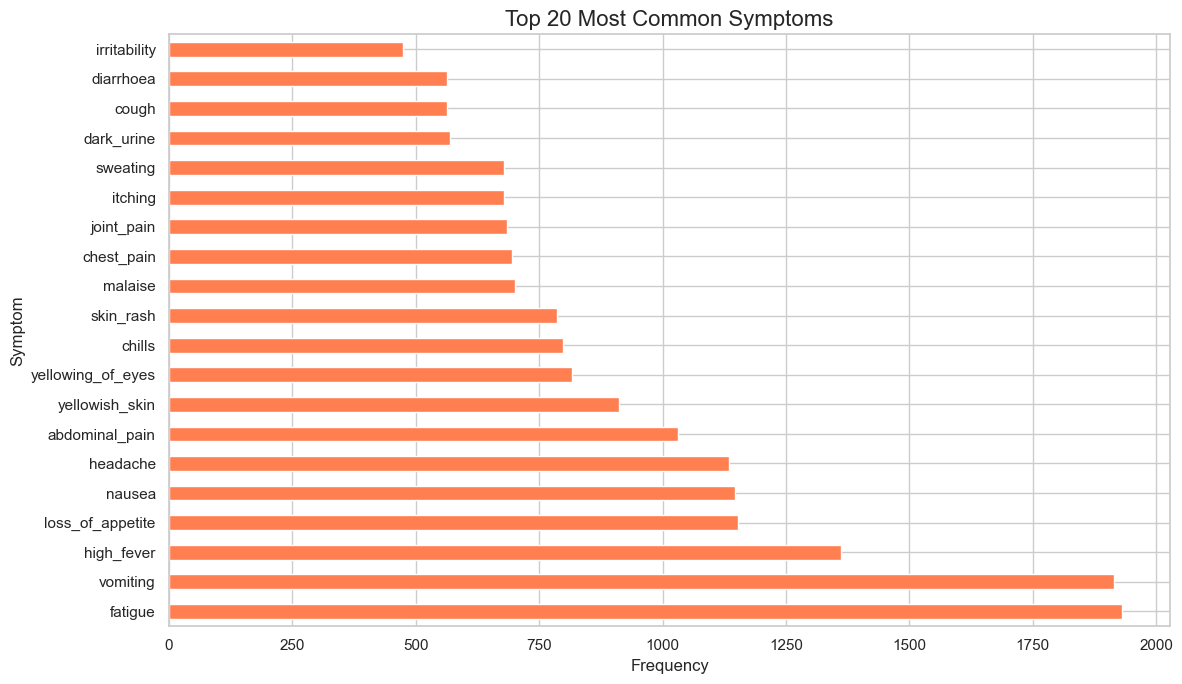

✅ Chart saved


In [ ]:
# Let's see which symptoms appear most frequently across all diseases
# This will tell us which symptoms are the most "diagnostic" — 
# meaning they help distinguish between diseases the most

symptom_counts = df_long['Symptom'].value_counts()

plt.figure(figsize=(12, 7))

symptom_counts.head(20).plot(kind='barh', color='coral')
# .head(20) means top 20 most frequent symptoms only
# color='coral' just makes it visually distinct from previous chart

plt.title('Top 20 Most Common Symptoms', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Symptom', fontsize=12)
plt.tight_layout()

plt.savefig('data/top_symptoms.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [ ]:
# We need to fix 3 specific symptoms that have spaces in wrong places
# .replace() on a Series replaces exact values with new values
# We pass a dictionary: {'old_value': 'new_value'}

df_long['Symptom'] = df_long['Symptom'].replace({
    'dischromic _patches': 'dischromic_patches',
    # space before underscore → clean underscore
    
    'foul_smell_of urine': 'foul_smell_of_urine',
    # space instead of underscore → clean underscore
    
    'spotting_ urination': 'spotting_urination'
    # space after underscore → clean underscore
})

# Fix the same symptoms in the original wide dataframe too
# We loop through every symptom column and apply the same fix
for col in symptom_cols:
    df[col] = df[col].replace({
        'dischromic _patches': 'dischromic_patches',
        'foul_smell_of urine': 'foul_smell_of_urine',
        'spotting_ urination': 'spotting_urination'
    })

print("Symptom names fixed")

✅ Symptom names fixed


In [ ]:
# We fix it in both dataframes

df['Disease'] = df['Disease'].replace({
    'hepatitis A': 'Hepatitis A'
})

df_long['Disease'] = df_long['Disease'].replace({
    'hepatitis A': 'Hepatitis A'
})

# Verify all 41 diseases now look consistent
print("All diseases after fixing:")
print(sorted(df['Disease'].unique()))
# sorted() so we can scan alphabetically and spot anything odd

All diseases after fixing:
['(vertigo) Paroymsal  Positional Vertigo', 'AIDS', 'Acne', 'Alcoholic hepatitis', 'Allergy', 'Arthritis', 'Bronchial Asthma', 'Cervical spondylosis', 'Chicken pox', 'Chronic cholestasis', 'Common Cold', 'Dengue', 'Diabetes', 'Dimorphic hemmorhoids(piles)', 'Drug Reaction', 'Fungal infection', 'GERD', 'Gastroenteritis', 'Heart attack', 'Hepatitis A', 'Hepatitis B', 'Hepatitis C', 'Hepatitis D', 'Hepatitis E', 'Hypertension', 'Hyperthyroidism', 'Hypoglycemia', 'Hypothyroidism', 'Impetigo', 'Jaundice', 'Malaria', 'Migraine', 'Osteoarthristis', 'Paralysis (brain hemorrhage)', 'Peptic ulcer diseae', 'Pneumonia', 'Psoriasis', 'Tuberculosis', 'Typhoid', 'Urinary tract infection', 'Varicose veins']


In [ ]:
# Let's do one final check on everything before we move to visualization
# This is our "sign off" that the data is clean

print("FINAL DATA QUALITY REPORT")
print(f"Total patient cases: {len(df)}")
# len() counts total rows

print(f"Total diseases: {df['Disease'].nunique()}")
print(f"Total unique symptoms: {df_long['Symptom'].nunique()}")
# After fixing, this might change slightly from 131

print(f"\nAny NaN in Disease column: {df['Disease'].isnull().any()}")
# .any() returns True if even one NaN exists, False if none

print(f"Any NaN in Symptom column (long format): {df_long['Symptom'].isnull().any()}")

print(f"\nDataset perfectly balanced: {df['Disease'].value_counts().std() == 0}")
# .std() is standard deviation — measures how spread out numbers are
# If std == 0, all values are identical → perfectly balanced
# std = 0 means True here, which is what we want



======= FINAL DATA QUALITY REPORT =======
Total patient cases: 4920
Total diseases: 41
Total unique symptoms: 131

Any NaN in Disease column: False
Any NaN in Symptom column (long format): False

Dataset perfectly balanced: True


In [ ]:
# Now let's explore the severity file
# Each symptom has a severity weight from 1-7
# Higher = more serious symptom
# This will be useful context later when Groq explains predictions

print("Severity dataframe info:")
print(sev_df.head(10))
print(f"\nSeverity weight range: {sev_df['weight'].min()} to {sev_df['weight'].max()}")

# Let's see the most severe symptoms
print("\nTop 15 most severe symptoms:")
print(sev_df.sort_values('weight', ascending=False).head(15))
# sort_values() sorts rows by a column
# ascending=False means highest first

Severity dataframe info:
                Symptom  weight
0               itching       1
1             skin_rash       3
2  nodal_skin_eruptions       4
3   continuous_sneezing       4
4             shivering       5
5                chills       3
6            joint_pain       3
7          stomach_pain       5
8               acidity       3
9      ulcers_on_tongue       4

Severity weight range: 1 to 7

Top 15 most severe symptoms:
                     Symptom  weight
113                     coma       7
46       swelling_of_stomach       7
56                chest_pain       7
57         weakness_in_limbs       7
25                high_fever       7
119  prominent_veins_on_calf       6
101    abnormal_menstruation       6
114         stomach_bleeding       6
102       dischromic_patches       6
84        spinning_movements       6
40                 diarrhoea       6
22         patches_in_throat       6
12       burning_micturition       6
44       acute_liver_failure       6
45     

In [ ]:
# We save our cleaned dataframes so Week 2 can load them directly
# We never want to redo cleaning — save once, reuse forever

df.to_csv('data/dataset_clean.csv', index=False)
# to_csv() converts dataframe back to CSV file
# index=False means don't write the row numbers (0,1,2...) as a column
# we don't need them saved, pandas adds them automatically when loading

df_long.to_csv('data/dataset_long.csv', index=False)

print("Clean data saved:")
print("  data/dataset_clean.csv  (wide format, for ML model)")
print("  data/dataset_long.csv   (long format, for analysis)")

✅ Clean data saved:
   → data/dataset_clean.csv  (wide format, for ML model)
   → data/dataset_long.csv   (long format, for analysis)


In [ ]:
# The vertigo disease name has two spaces between words
# 'Paroymsal  Positional' should be 'Paroymsal Positional'
# .replace() fixes this in both dataframes

df['Disease'] = df['Disease'].replace({
    '(vertigo) Paroymsal  Positional Vertigo': '(vertigo) Paroxysmal Positional Vertigo'
})
# Note: 'Paroymsal' is also a typo in the dataset — correct is 'Paroxysmal'
# We fix both the spelling AND the double space in one go

df_long['Disease'] = df_long['Disease'].replace({
    '(vertigo) Paroymsal  Positional Vertigo': '(vertigo) Paroxysmal Positional Vertigo'
})

# Save again with this final fix
df.to_csv('data/dataset_clean.csv', index=False)
df_long.to_csv('data/dataset_long.csv', index=False)

print("Vertigo name fixed and files resaved")

✅ Vertigo name fixed and files resaved


In [ ]:
df_long.columns

Index(['Disease', 'variable', 'Symptom'], dtype='str')

TypeError: 'DataFrame' object is not callable

In [ ]:
print(sorted(df['Disease'].unique()))


['(vertigo) Paroxysmal Positional Vertigo', 'AIDS', 'Acne', 'Alcoholic hepatitis', 'Allergy', 'Arthritis', 'Bronchial Asthma', 'Cervical spondylosis', 'Chicken pox', 'Chronic cholestasis', 'Common Cold', 'Dengue', 'Diabetes', 'Dimorphic hemmorhoids(piles)', 'Drug Reaction', 'Fungal infection', 'GERD', 'Gastroenteritis', 'Heart attack', 'Hepatitis A', 'Hepatitis B', 'Hepatitis C', 'Hepatitis D', 'Hepatitis E', 'Hypertension', 'Hyperthyroidism', 'Hypoglycemia', 'Hypothyroidism', 'Impetigo', 'Jaundice', 'Malaria', 'Migraine', 'Osteoarthristis', 'Paralysis (brain hemorrhage)', 'Peptic ulcer diseae', 'Pneumonia', 'Psoriasis', 'Tuberculosis', 'Typhoid', 'Urinary tract infection', 'Varicose veins']


In [ ]:
# We're building a matrix (grid) where:
# Rows = diseases (41)
# Columns = symptoms (131)
# Cell value = 1 if that disease has that symptom, 0 if not
# Then we color it — 1 is colored, 0 is blank
# This lets us SEE the symptom fingerprint of each disease

# Step 1: Get all unique diseases and symptoms as sorted lists
all_diseases = sorted(df_long['Disease'].unique())
all_symptoms = sorted(df_long['Symptom'].unique())

# Step 2: Create an empty grid of zeros
# np.zeros() creates a matrix filled with 0s
# shape = (number of rows, number of columns)
matrix = np.zeros((len(all_diseases), len(all_symptoms)))
# This creates a 41 x 131 grid, all zeros to start

# Step 3: Fill in 1s where a disease has a symptom
for i, disease in enumerate(all_diseases):
    # enumerate gives us both index (i) and value (disease) as we loop
    
    # Get all symptoms for this specific disease
    disease_symptoms = df_long[df_long['Disease'] == disease]['Symptom'].unique()
    # df_long[df_long['Disease'] == disease] filters rows for this disease only
    # ['Symptom'] gets just the symptom column
    # .unique() removes any duplicates
    
    for symptom in disease_symptoms:
        if symptom in all_symptoms:
            j = all_symptoms.index(symptom)
            # .index() finds the position of this symptom in our list
            matrix[i][j] = 1
            # Put a 1 at row i (disease), column j (symptom)

# Step 4: Convert to DataFrame for seaborn
matrix_df = pd.DataFrame(
    matrix,
    index=all_diseases,    # row labels = disease names
    columns=all_symptoms   # column labels = symptom names
)

print(f"Heatmap matrix shape: {matrix_df.shape}")


Heatmap matrix shape: (41, 131)
✅ Matrix built — rendering heatmap now...


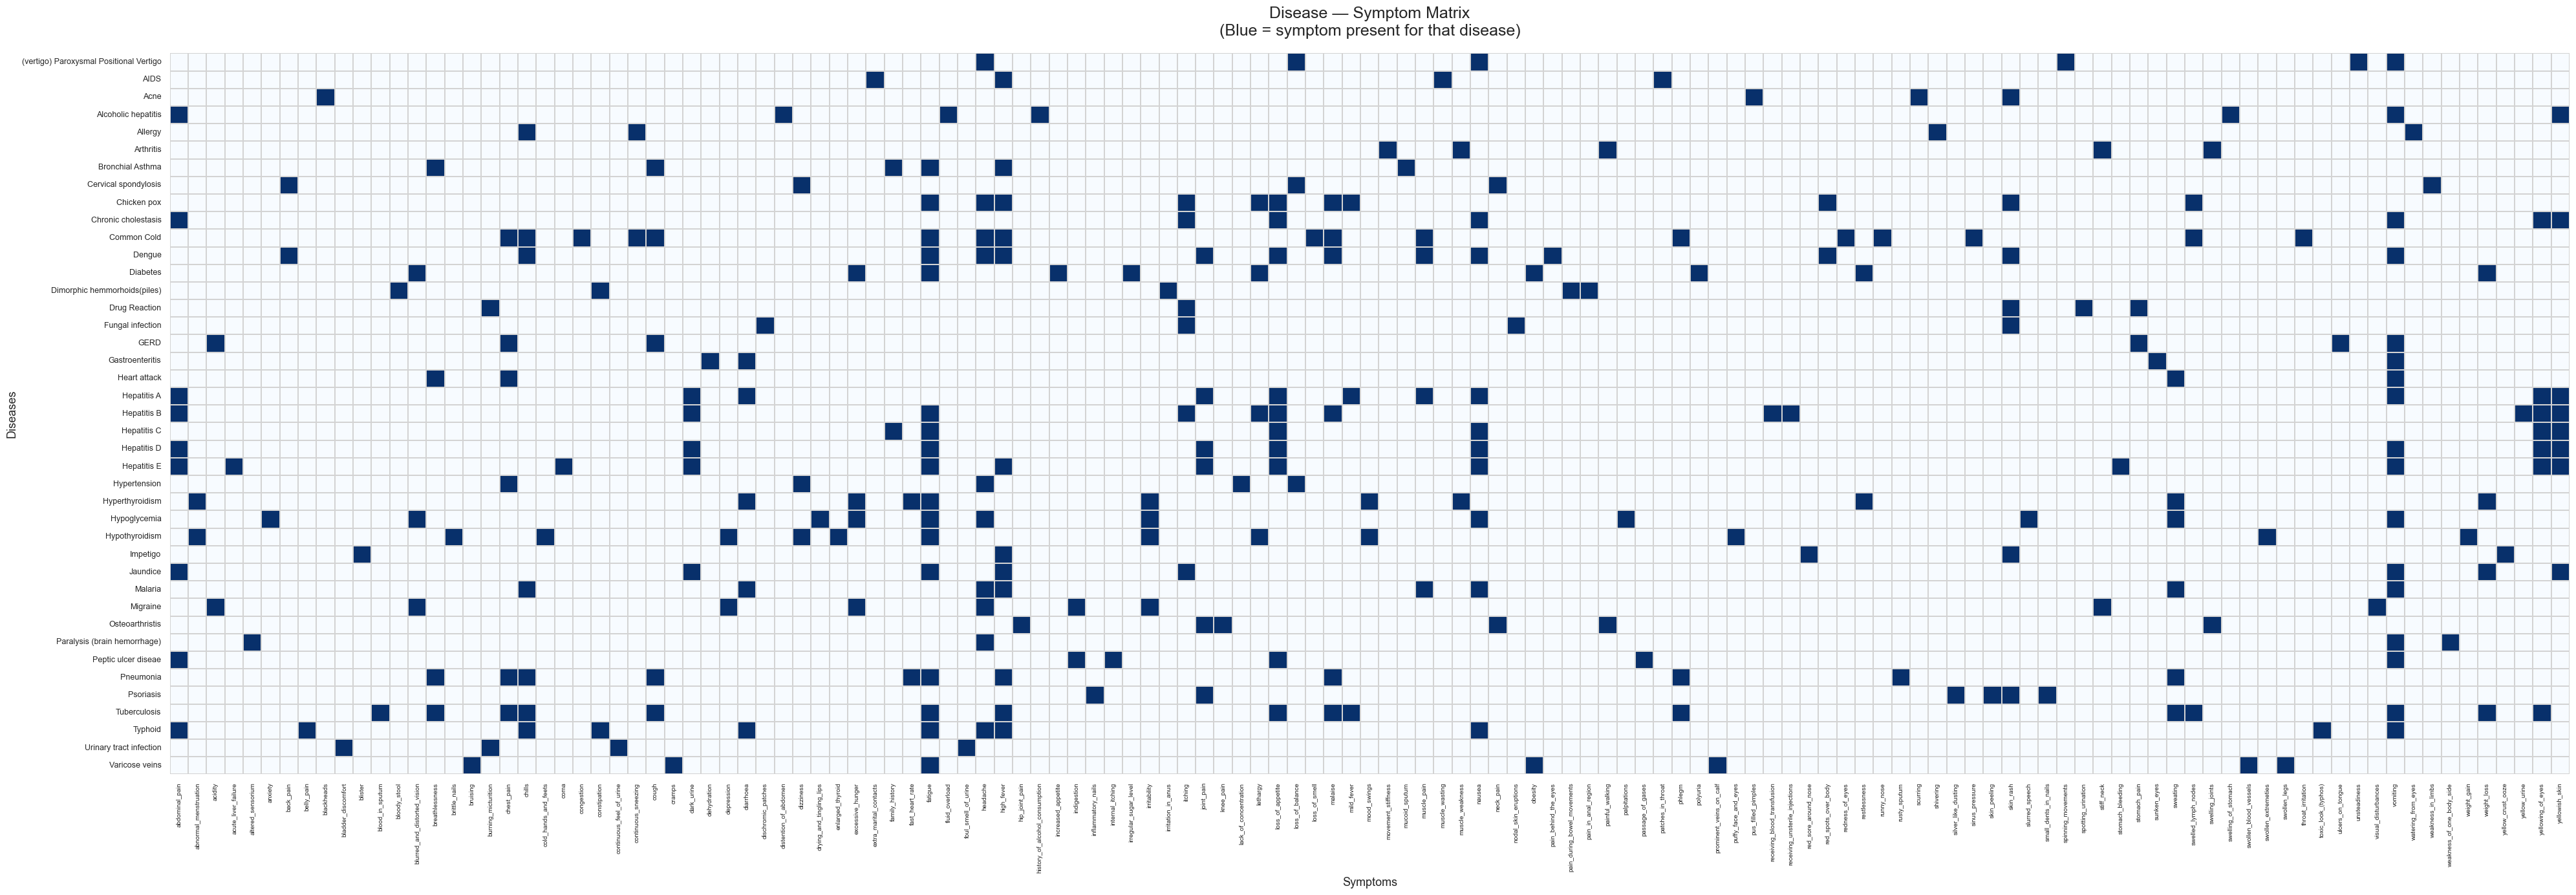

✅ Heatmap saved to data/disease_symptom_heatmap.png


In [ ]:
# 41 diseases x 131 symptoms is a big chart

plt.figure(figsize=(40, 14))
# We need a very wide figure to fit 131 symptom columns

sns.heatmap(
    matrix_df,
    cmap='Blues',
    # cmap = color map
    # 'Blues' means 0 = white, 1 = dark blue
    
    linewidths=0.3,
    # thin lines between cells so we can see individual boxes
    
    linecolor='lightgray',
    # color of those dividing lines
    
    cbar=False,
    # cbar = color bar legend on the side
    # False because we only have 0 and 1, no need for gradient legend
    
    xticklabels=True,
    yticklabels=True
    # Show both symptom names (x axis) and disease names (y axis)
)

plt.title('Disease — Symptom Matrix\n(Blue = symptom present for that disease)',
          fontsize=18, pad=20)
# pad=20 adds space between title and chart

plt.xlabel('Symptoms', fontsize=13)
plt.ylabel('Diseases', fontsize=13)

plt.xticks(fontsize=7, rotation=90)
# rotation=90 rotates symptom names vertically so they don't overlap
# fontsize=7 makes them small enough to fit

plt.yticks(fontsize=9, rotation=0)
# rotation=0 keeps disease names horizontal

plt.tight_layout()

plt.savefig('data/disease_symptom_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Heatmap saved to data/disease_symptom_heatmap.png")

In [ ]:
# Final cell — a clean summary of everything we learned this week
# This is what you'd present to a team or write in a project report

print("=" * 50)
print("        WEEK 1 — EDA COMPLETE SUMMARY")
print("=" * 50)

print(f"\n Dataset size:        {len(df)} patient cases")
print(f" Diseases to predict: {df['Disease'].nunique()}")
print(f" Unique symptoms:     {df_long['Symptom'].nunique()}")
print(f"  Dataset balanced:    {df['Disease'].value_counts().std() == 0}")
print(f" Missing values:      {df.isnull().sum().sum()} total NaN in clean data")
# .sum().sum() = sum all columns, then sum those sums = grand total

print(f"\nFiles saved:")
print(f"   data/dataset_clean.csv          (wide format for ML)")
print(f"   data/dataset_long.csv           (long format for analysis)")
print(f"   data/disease_distribution.png   (bar chart)")
print(f"   data/top_symptoms.png           (top symptoms chart)")
print(f"   data/disease_symptom_heatmap.png (the big heatmap)")

print("=" * 50)

        WEEK 1 — EDA COMPLETE SUMMARY

📊 Dataset size:        4920 patient cases
🦠 Diseases to predict: 41
🔬 Unique symptoms:     131
⚖️  Dataset balanced:    True
🧹 Missing values:      46992 total NaN in clean data

📁 Files saved:
   data/dataset_clean.csv          (wide format for ML)
   data/dataset_long.csv           (long format for analysis)
   data/disease_distribution.png   (bar chart)
   data/top_symptoms.png           (top symptoms chart)
   data/disease_symptom_heatmap.png (the big heatmap)

✅ Ready for Week 2 — ML Model Training
